# EDA - Skin Dataset Classification

Esta notebook realiza el análisis exploratorio del dataset luego de eliminar duplicados exactos y crear un split estratificado con test fijo y 5-fold cross-validation sobre trainval.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import math

SPLIT_CSV = Path("../data/splits/final_split_5fold.csv")
DUPLICATE_CSV = Path("../data/splits/duplicate_report.csv")
OUTPUT_DIR = Path("../results/eda")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(SPLIT_CSV)
dup_df = pd.read_csv(DUPLICATE_CSV)

print("Columnas del split final:")
print(df.columns.tolist())

print("\nPrimeras filas:")
display(df.head())

Columnas del split final:
['path', 'split_original', 'class', 'hash', 'duplicate_group_id', 'is_duplicate', 'kept', 'subset', 'fold']

Primeras filas:


,path,split_original,class,hash,duplicate_group_id,is_duplicate,kept,subset,fold
0,data\Split_smol\train\Benign keratosis\ISIC_00...,train,Benign keratosis,6080589bc5659c5fb69584728c1ecff7a48a4117b2b4f8...,NaN,False,True,trainval,4
1,data\Split_smol\train\Atopic Dermatitis\2_0.jpg,train,Atopic Dermatitis,aaeae1851476d0a31aac28bc6f00b2448f6782e0ceb91a...,NaN,False,True,trainval,0
2,data\Split_smol\train\Squamous cell carcinoma\...,train,Squamous cell carcinoma,74bbb0a50940d052144d85317fcf14c2f9a5e172ee3ec5...,NaN,False,True,trainval,1
3,data\Split_smol\val\Actinic keratosis\ISIC_003...,val,Actinic keratosis,d21da15b541845d4401cece15bb8dc8ef138cbde8dadca...,NaN,False,True,trainval,0
4,data\Split_smol\train\Actinic keratosis\ISIC_0...,train,Actinic keratosis,cd77a6ca1e6ec9c9b763922ff6e43529a7578fb2494150...,NaN,False,True,trainval,0


Total de imágenes originales analizadas: 878
Total de imágenes limpias usadas: 844
Cantidad de clases: 9


,cantidad
class,
Actinic keratosis,100
Atopic Dermatitis,80
Benign keratosis,100
Dermatofibroma,100
Melanocytic nevus,100
Melanoma,100
Squamous cell carcinoma,100
Tinea Ringworm Candidiasis,64
Vascular lesion,100


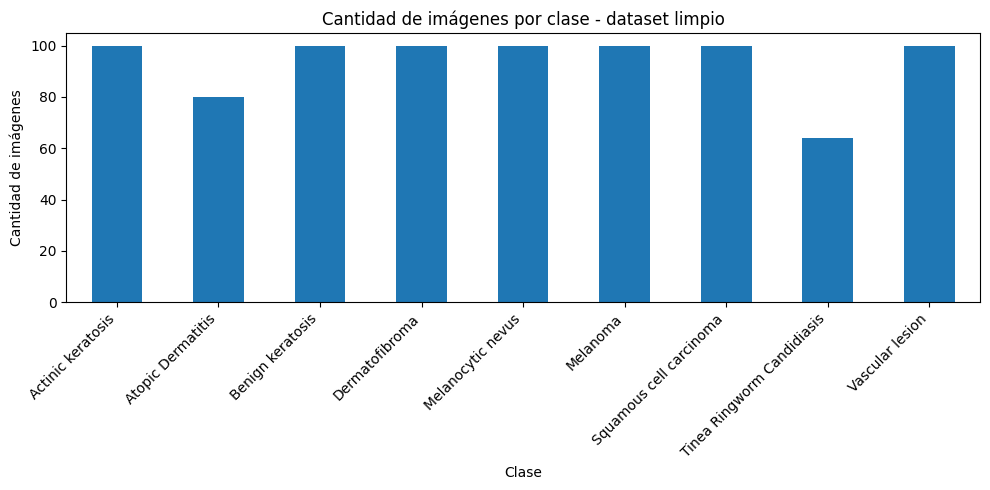

In [2]:
total_original = len(dup_df)
total_clean = len(df)
num_classes = df["class"].nunique()

print(f"Total de imágenes originales analizadas: {total_original}")
print(f"Total de imágenes limpias usadas: {total_clean}")
print(f"Cantidad de clases: {num_classes}")

class_counts = df["class"].value_counts().sort_index()

display(class_counts.rename("cantidad").to_frame())

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Cantidad de imágenes por clase - dataset limpio")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution_clean.png", dpi=300)
plt.show()

In [3]:
dup_df["kept"] = dup_df["kept"].astype(str).str.lower().eq("true")

total_duplicates_excluded = (~dup_df["kept"]).sum()
duplicate_groups = dup_df["duplicate_group_id"].dropna()
duplicate_groups = duplicate_groups[duplicate_groups.astype(str) != ""].nunique()

print(f"Imágenes originales analizadas: {len(dup_df)}")
print(f"Imágenes duplicadas excluidas: {total_duplicates_excluded}")
print(f"Grupos de duplicados encontrados: {duplicate_groups}")

duplicates_only = dup_df[~dup_df["kept"]].copy()
display(duplicates_only.head(20))

Imágenes originales analizadas: 878
Imágenes duplicadas excluidas: 34
Grupos de duplicados encontrados: 34


,path,split_original,class,hash,duplicate_group_id,is_duplicate,kept
81,data\Split_smol\val\Atopic Dermatitis\1_14.jpg,val,Atopic Dermatitis,8756835a808b41799ac405ffb47cf400542e808ca2625f...,81.0,True,False
83,data\Split_smol\val\Atopic Dermatitis\1_15.jpg,val,Atopic Dermatitis,be78206a356b2d6c8d9ceb33f9a57dca88740446599e26...,82.0,True,False
85,data\Split_smol\val\Atopic Dermatitis\1_16.jpg,val,Atopic Dermatitis,bcf8193f91f816fad8765b930ba7b4fd1c80f7286e0a90...,83.0,True,False
87,data\Split_smol\val\Atopic Dermatitis\1_17.jpg,val,Atopic Dermatitis,a071e39cf5f81884e84f53e9a8ac8b4f69dbcbc1ffc957...,84.0,True,False
89,data\Split_smol\val\Atopic Dermatitis\1_18.jpg,val,Atopic Dermatitis,489a0439b5c7878aeda2d8f94fc842e2ee9974e1f7a835...,85.0,True,False
91,data\Split_smol\val\Atopic Dermatitis\1_19.jpg,val,Atopic Dermatitis,3647eafda5848976734a61ed050a66fccbe0142ebb80d8...,86.0,True,False
93,data\Split_smol\val\Atopic Dermatitis\1_20.jpg,val,Atopic Dermatitis,e64b4f63d8fe3e41b6eaa56cf1e36ba3bc82b778fbc7f5...,87.0,True,False
97,data\Split_smol\val\Atopic Dermatitis\1_23.jpg,val,Atopic Dermatitis,e9b302de72ebee8eb2f5a0316c3969ebf7e3e529570657...,90.0,True,False
99,data\Split_smol\val\Atopic Dermatitis\1_24.jpg,val,Atopic Dermatitis,0ceb5385a0f81ab371f4fd091107337b54dde8b51b071f...,91.0,True,False
101,data\Split_smol\val\Atopic Dermatitis\1_25.jpg,val,Atopic Dermatitis,a79c4741a3be4ea48ac6fd95c0745b4688c8356732e38c...,92.0,True,False


,cantidad
subset,
trainval,717
test,127


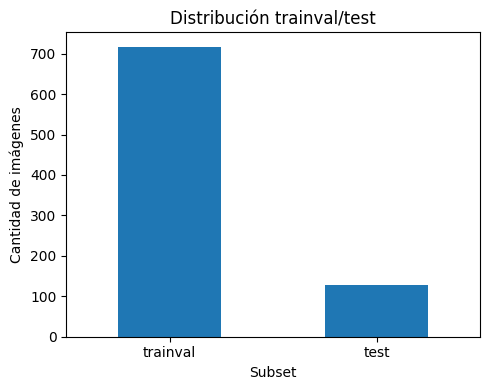

Porcentajes:


,porcentaje
subset,
trainval,84.95
test,15.05


In [4]:
subset_counts = df["subset"].value_counts()

display(subset_counts.rename("cantidad").to_frame())

plt.figure(figsize=(5, 4))
subset_counts.plot(kind="bar")
plt.title("Distribución trainval/test")
plt.xlabel("Subset")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "subset_distribution.png", dpi=300)
plt.show()

print("Porcentajes:")
display((subset_counts / len(df) * 100).round(2).rename("porcentaje").to_frame())

,cantidad_test
class,
Actinic keratosis,15
Atopic Dermatitis,12
Benign keratosis,15
Dermatofibroma,15
Melanocytic nevus,15
Melanoma,15
Squamous cell carcinoma,15
Tinea Ringworm Candidiasis,10
Vascular lesion,15


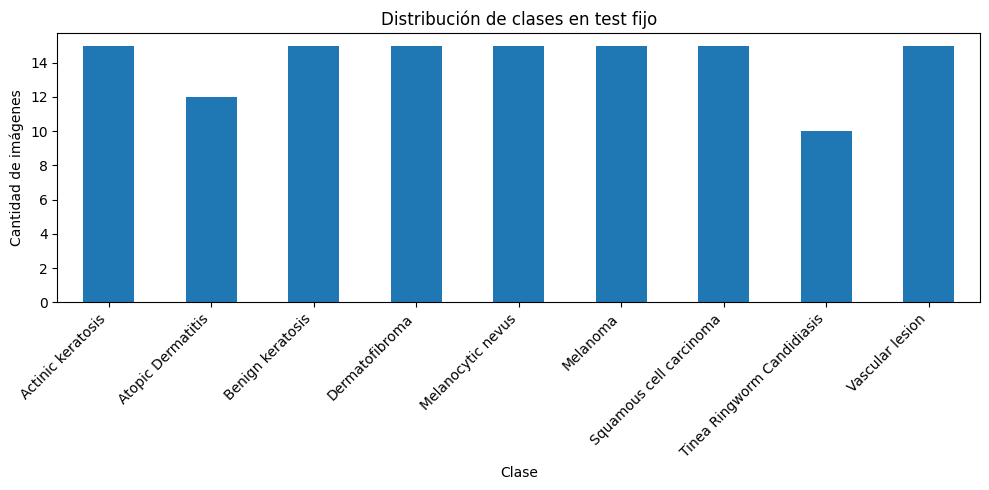

In [5]:
test_df = df[df["subset"] == "test"]

test_class_counts = test_df["class"].value_counts().sort_index()

display(test_class_counts.rename("cantidad_test").to_frame())

plt.figure(figsize=(10, 5))
test_class_counts.plot(kind="bar")
plt.title("Distribución de clases en test fijo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_class_distribution.png", dpi=300)
plt.show()

class,Actinic keratosis,Atopic Dermatitis,Benign keratosis,Dermatofibroma,Melanocytic nevus,Melanoma,Squamous cell carcinoma,Tinea Ringworm Candidiasis,Vascular lesion
fold,,,,,,,,,
0,17,14,17,17,17,17,17,11,17
1,17,14,17,17,17,17,17,11,17
2,17,14,17,17,17,17,17,10,17
3,17,13,17,17,17,17,17,11,17
4,17,13,17,17,17,17,17,11,17


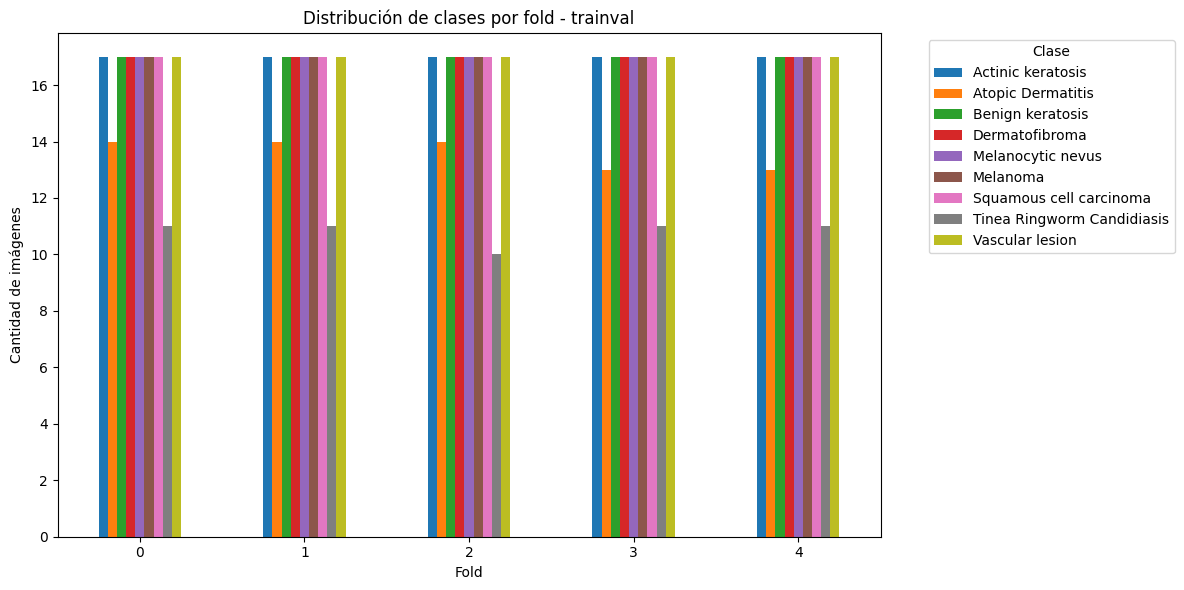

In [6]:
trainval_df = df[df["subset"] == "trainval"].copy()

fold_table = pd.crosstab(trainval_df["fold"], trainval_df["class"])

display(fold_table)

fold_table.plot(kind="bar", figsize=(12, 6))
plt.title("Distribución de clases por fold - trainval")
plt.xlabel("Fold")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=0)
plt.legend(title="Clase", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fold_class_distribution.png", dpi=300)
plt.show()

,path,class,subset,fold,width,height,aspect_ratio
0,data\Split_smol\train\Benign keratosis\ISIC_00...,Benign keratosis,trainval,4,1024,764,1.340314
1,data\Split_smol\train\Atopic Dermatitis\2_0.jpg,Atopic Dermatitis,trainval,0,294,222,1.324324
2,data\Split_smol\train\Squamous cell carcinoma\...,Squamous cell carcinoma,trainval,1,600,450,1.333333
3,data\Split_smol\val\Actinic keratosis\ISIC_003...,Actinic keratosis,trainval,0,600,450,1.333333
4,data\Split_smol\train\Actinic keratosis\ISIC_0...,Actinic keratosis,trainval,0,600,450,1.333333


Resumen de resoluciones:


,width,height,aspect_ratio
count,844.000000,844.000000,844.000000
mean,704.204976,529.844787,1.324940
std,252.775566,186.058622,0.102252
min,72.000000,76.000000,0.467005
25%,600.000000,450.000000,1.333333
50%,600.000000,450.000000,1.333333
75%,1024.000000,764.000000,1.333333
max,1200.000000,1280.000000,1.764706


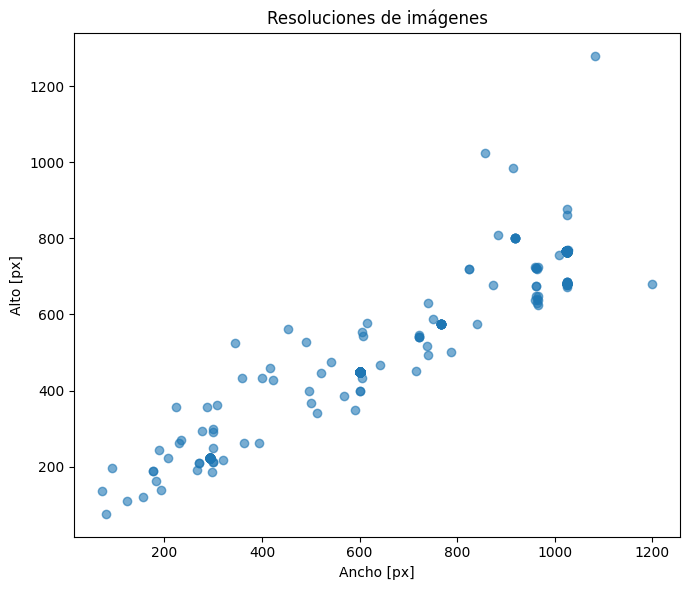

cantidad
width height          
600   450          400
1024  768          135
294   222           80
1024  764           74
1022  767           21
767   576           12
919   802            6
1024  681            5
      679            4
      682            4
      680            4
      683            3
962   722            3
      674            2
722   542            2
300   213            2
1024  686            2
177   189            2
270   210            2
824   719            2

In [7]:
resolutions = []

for _, row in df.iterrows():
    img_path = Path("..") / row["path"]
    
    with Image.open(img_path) as img:
        width, height = img.size
    
    resolutions.append({
        "path": row["path"],
        "class": row["class"],
        "subset": row["subset"],
        "fold": row["fold"],
        "width": width,
        "height": height,
        "aspect_ratio": width / height,
    })

res_df = pd.DataFrame(resolutions)

display(res_df.head())

res_df.to_csv(OUTPUT_DIR / "image_resolutions.csv", index=False)

print("Resumen de resoluciones:")
display(res_df[["width", "height", "aspect_ratio"]].describe())


plt.figure(figsize=(7, 6))
plt.scatter(res_df["width"], res_df["height"], alpha=0.6)
plt.title("Resoluciones de imágenes")
plt.xlabel("Ancho [px]")
plt.ylabel("Alto [px]")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "resolution_scatter.png", dpi=300)
plt.show()

resolution_counts = res_df.groupby(["width", "height"]).size().sort_values(ascending=False)
display(resolution_counts.rename("cantidad").head(20).to_frame())

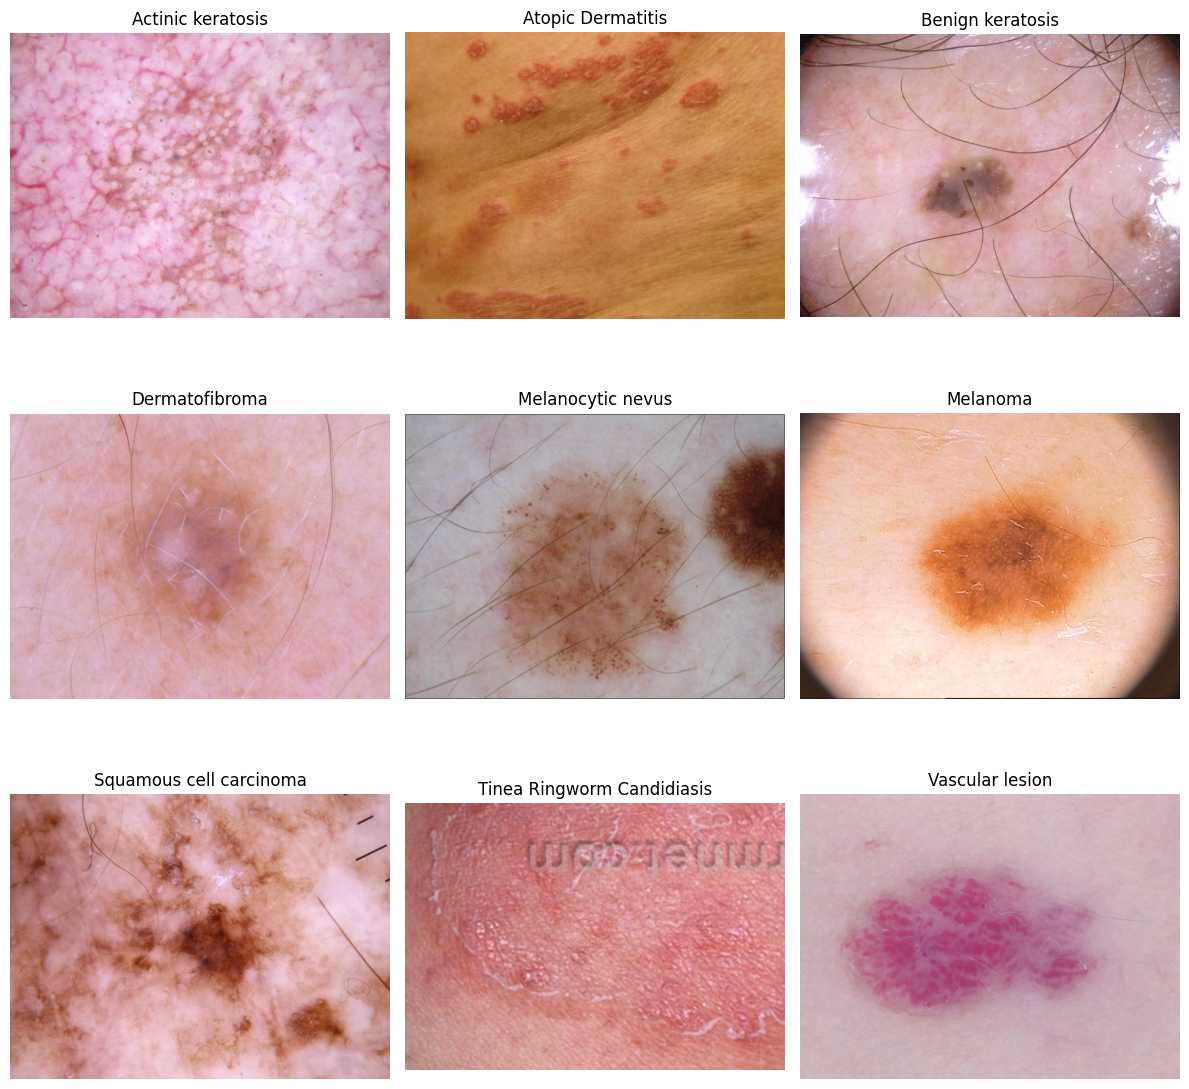

In [8]:
classes = sorted(df["class"].unique())
n_classes = len(classes)

cols = 3
rows = math.ceil(n_classes / cols)

plt.figure(figsize=(12, 4 * rows))

for i, class_name in enumerate(classes):
    sample_row = df[df["class"] == class_name].sample(1, random_state=42).iloc[0]
    img_path = Path("..") / sample_row["path"]
    
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_images_by_class.png", dpi=300)
plt.show()

In [9]:
summary = f"""
EDA summary

Total de imágenes originales analizadas: {total_original}
Total de imágenes limpias usadas: {total_clean}
Cantidad de clases: {num_classes}
Imágenes duplicadas excluidas: {total_duplicates_excluded}
Grupos de duplicados encontrados: {duplicate_groups}

Trainval: {len(trainval_df)}
Test fijo: {len(test_df)}

Folds en trainval: {sorted(trainval_df["fold"].unique().tolist())}

Archivos generados en results/eda:
- class_distribution_clean.png
- subset_distribution.png
- test_class_distribution.png
- fold_class_distribution.png
- resolution_scatter.png
- sample_images_by_class.png
- image_resolutions.csv
"""

print(summary)

with open(OUTPUT_DIR / "eda_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary)


EDA summary

Total de imágenes originales analizadas: 878
Total de imágenes limpias usadas: 844
Cantidad de clases: 9
Imágenes duplicadas excluidas: 34
Grupos de duplicados encontrados: 34

Trainval: 717
Test fijo: 127

Folds en trainval: [0, 1, 2, 3, 4]

Archivos generados en results/eda:
- class_distribution_clean.png
- subset_distribution.png
- test_class_distribution.png
- fold_class_distribution.png
- resolution_scatter.png
- sample_images_by_class.png
- image_resolutions.csv

